In [1]:
#importing cell

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# Richness Analysis

In [2]:
# functions cell

def plots(mean_matrix,ax_label,lab):    
    fig = plt.figure(tight_layout=True, figsize=(10,5))
    gs = gridspec.GridSpec(2, 2, height_ratios=(1,1))
    fig.suptitle("Mean Richness vs Leakage and " + ax_label + " (100 runs)",fontsize=10)

    ax = fig.add_subplot(gs[:, 0])
    ax.imshow(mean_matrix, cmap="RdBu_r")
    ax.set_xlabel("Leakage")
    ax.set_ylabel(ax_label)

    for i in range(len(wk)):
        for j in range(len(leakage)):
            ax.annotate(np.round(mean_matrix[i, j],3), xy=(j, i), ha='center', va='center', color='black') 
    ax.set_xticks(range(len(leakage)), leakage, rotation=30)
    ax.set_yticks(range(len(wk)), wk)

    ax = fig.add_subplot(gs[0, 1])
    ax.grid(alpha=0.5)
    for i,j in zip(range(len(wk)),wk):
        ax.scatter(leakage,mean_matrix[i],marker=".")
        ax.plot(leakage,mean_matrix[i],label= lab + " = {}".format(j),alpha=0.5)
        ax.set_xticks(leakage)
        ax.set_xlabel("Leakage")
        ax.set_ylabel("Mean Richness")
        ax.legend(loc=2,fontsize=8)

    ax = fig.add_subplot(gs[1, 1])
    ax.grid(alpha=0.5)
    for i,j in zip(range(mean_matrix.shape[0]),leakage):
        ax.scatter(wk,mean_matrix[:,i],marker=".")
        ax.plot(wk,mean_matrix[:,i],label="$l=${}".format(j),alpha=0.5)
        ax.set_xlabel(ax_label)
        ax.set_ylabel("Mean Richness")
        ax.set_xscale("log")
        ax.legend(loc=2,fontsize=8)


def comparison_plots(l_00,abs_diff_00,leakage):
    colors=["tab:orange","tab:green","tab:red"]

    fig, ax = plt.subplots(1,2, figsize=(12,4))
    fig.suptitle("leakage = {}".format(leakage))

    ax[0].set(title=r"Mean Richness vs $w_\alpha k_\alpha$")
    ax[0].set_xlabel(r"$w_\alpha k_\alpha$")
    ax[0].set_ylabel("Mean Richness")
    for i in range(l_00.shape[0]):
        ax[0].plot(wk,l_00[i],label="{} external resources".format(i+1))
        ax[0].scatter(wk,l_00[i],marker=".")
    ax[0].set_xscale("log")
    ax[0].grid(alpha=0.5)
    ax[0].legend(fontsize=8);

    ax[1].set(title="Difference from 1 external resource")
    ax[1].set_xlabel(r"$w_\alpha k_\alpha$")
    ax[1].set_ylabel("Mean Richness Difference")
    for i in range(abs_diff_00.shape[0]):
        ax[1].plot(wk,abs_diff_00[i],c=colors[i],label="{} external resources".format(i+2))
        ax[1].scatter(wk,abs_diff_00[i],marker=".",c=colors[i])
    ax[1].set_xscale("log")
    ax[1].grid(alpha=0.5)
    ax[1].legend(fontsize=8);

In [3]:
# simulations prarams:

params = pd.read_csv("grid_search_richness/params_GS_richness.csv")
params = pd.DataFrame(params.iloc[0].drop("Unnamed: 0"))

leakage=np.round(np.linspace(0.001,0.9,num=5),3)
wk=np.logspace(0, 3, num=5, base=10)
wk=np.round(wk,0)
wk=wk[::-1]

heat_map_values = pd.DataFrame({"Leakage":leakage, "k_alpha":wk})

In [4]:
params

,0
S_tot,80
S,40
R,40
S0,10
R0,5
time_period,100000.0
t_step,0.1
num_F,4
num_T,4
partition_F,20


In [5]:
heat_map_values

,Leakage,k_alpha
0,0.001,1000.0
1,0.226,178.0
2,0.450,32.0
3,0.675,6.0
4,0.900,1.0


### 1. One external resource ($\alpha=0$)

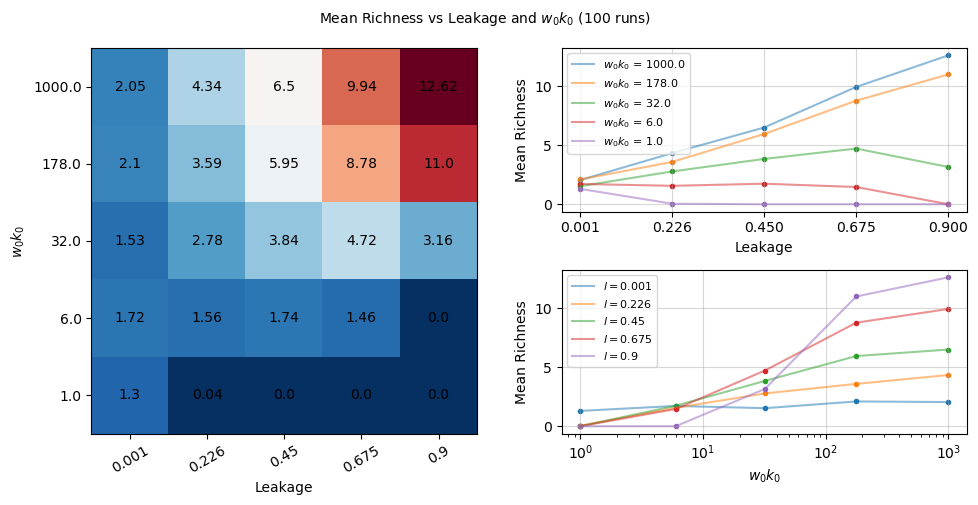

In [6]:
mean_matrix_1_resource = np.genfromtxt("grid_search_richness/mean_richness_1_resources.csv", delimiter=",")
plots(mean_matrix_1_resource,"$w_0k_0$","$w_0k_0$")

### 2. Two external resources ($\alpha=0,10$)

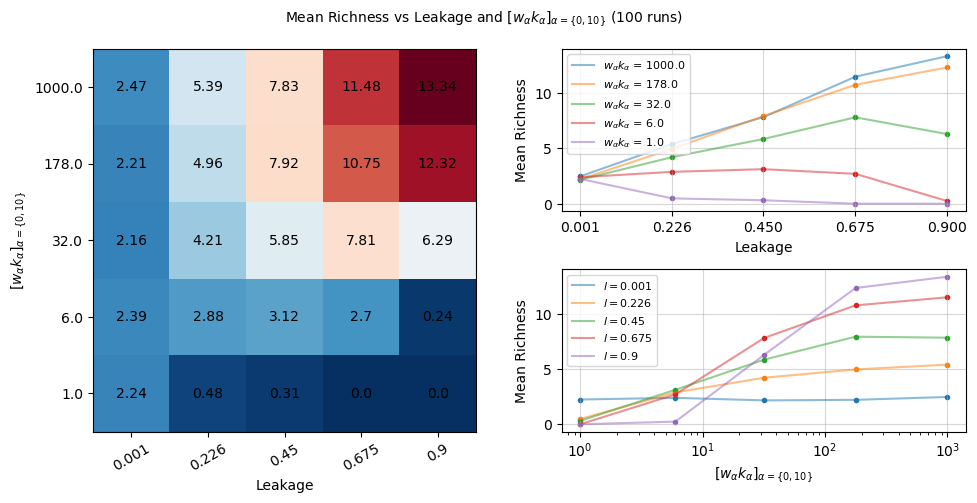

In [7]:
mean_matrix_2_resource = np.genfromtxt("grid_search_richness_2_resources/mean_richness_2_resources.csv", delimiter=",")
plots(mean_matrix_2_resource,r"$[w_\alpha k_\alpha]_{\alpha=\{0,10\}}$",r"$w_\alpha k_\alpha$")

### 3. Three external resources ($\alpha=0,10,20$)

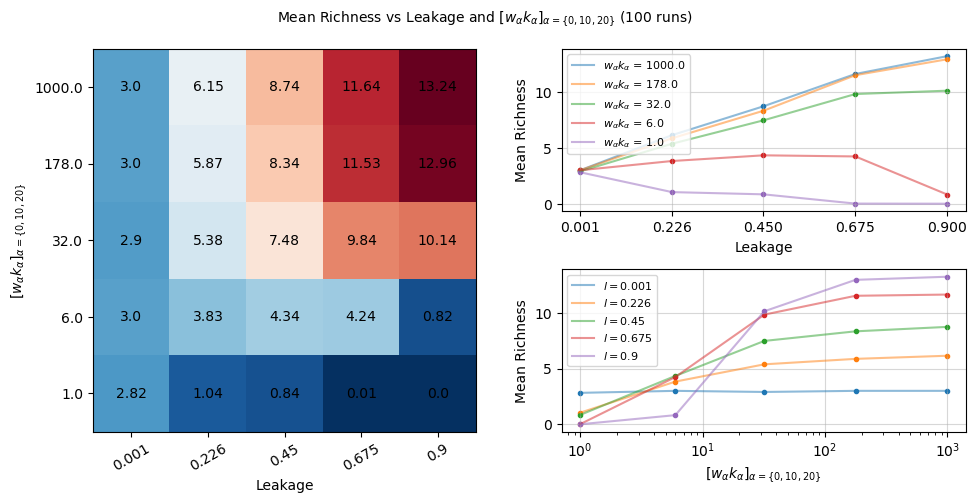

In [8]:
mean_matrix_3_resource = np.genfromtxt("grid_search_richness_3_resources/mean_richness_3_resources.csv", delimiter=",")
plots(mean_matrix_3_resource,r"$[w_\alpha k_\alpha]_{\alpha=\{0,10,20\}}$",r"$w_\alpha k_\alpha$")

### 4. Four external resources ($\alpha=0,10,20,30$)

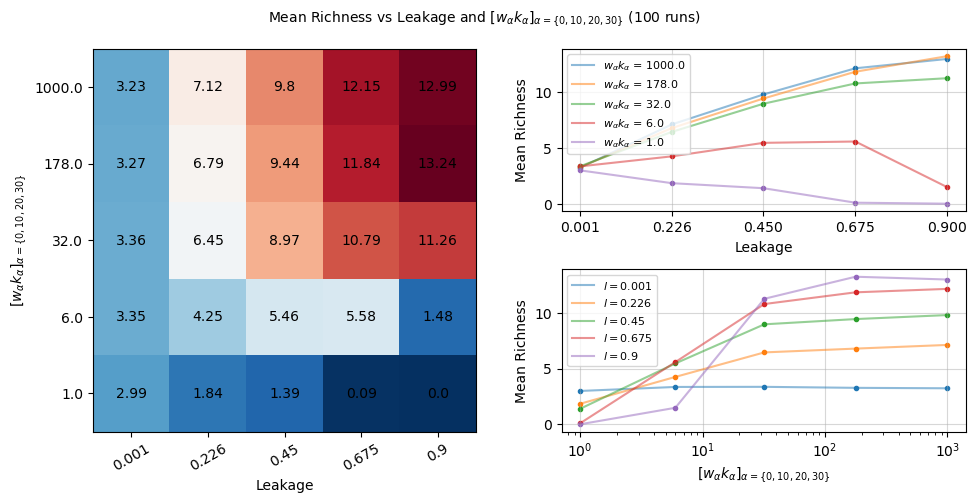

In [9]:
mean_matrix_4_resource = np.genfromtxt("grid_search_richness_4_resources/mean_richness_4_resources.csv", delimiter=",")
plots(mean_matrix_4_resource,r"$[w_\alpha k_\alpha]_{\alpha=\{0,10,20,30\}}$",r"$w_\alpha k_\alpha$")

### 5. Comparison:

In [10]:
l_0001_1 = mean_matrix_1_resource[:,0]
l_0001_2 = mean_matrix_2_resource[:,0]
l_0001_3 = mean_matrix_3_resource[:,0]
l_0001_4 = mean_matrix_4_resource[:,0]

l_0001 = np.array([l_0001_1,l_0001_2,l_0001_3,l_0001_4])

abs_diff_0001=np.zeros_like(l_0001)
for i in range(l_0001.shape[0]):
    abs_diff_0001[i] = np.abs(l_0001[0]-l_0001[i])

abs_diff_0001 = abs_diff_0001[1:,:]

#------------------------------------------------------------

l_0226_1 = mean_matrix_1_resource[:,1]
l_0226_2 = mean_matrix_2_resource[:,1]
l_0226_3 = mean_matrix_3_resource[:,1]
l_0226_4 = mean_matrix_4_resource[:,1]

l_0226 = np.array([l_0226_1,l_0226_2,l_0226_3,l_0226_4])

abs_diff_0226=np.zeros_like(l_0226)
for i in range(l_0226.shape[0]):
    abs_diff_0226[i] = np.abs(l_0226[0]-l_0226[i])

abs_diff_0226 = abs_diff_0226[1:,:]

#------------------------------------------------------------

l_045_1 = mean_matrix_1_resource[:,2]
l_045_2 = mean_matrix_2_resource[:,2]
l_045_3 = mean_matrix_3_resource[:,2]
l_045_4 = mean_matrix_4_resource[:,2]

l_045 = np.array([l_045_1,l_045_2,l_045_3,l_045_4])

abs_diff_045=np.zeros_like(l_045)
for i in range(l_045.shape[0]):
    abs_diff_045[i] = np.abs(l_045[0]-l_045[i])

abs_diff_045 = abs_diff_045[1:,:]

#------------------------------------------------------------

l_0675_1 = mean_matrix_1_resource[:,3]
l_0675_2 = mean_matrix_2_resource[:,3]
l_0675_3 = mean_matrix_3_resource[:,3]
l_0675_4 = mean_matrix_4_resource[:,3]

l_0675 = np.array([l_0675_1,l_0675_2,l_0675_3,l_0675_4])

abs_diff_0675=np.zeros_like(l_0675)
for i in range(l_0675.shape[0]):
    abs_diff_0675[i] = np.abs(l_0675[0]-l_0675[i])

abs_diff_0675 = abs_diff_0675[1:,:]

#------------------------------------------------------------

l_09_1 = mean_matrix_1_resource[:,4]
l_09_2 = mean_matrix_2_resource[:,4]
l_09_3 = mean_matrix_3_resource[:,4]
l_09_4 = mean_matrix_4_resource[:,4]

l_09 = np.array([l_09_1,l_09_2,l_09_3,l_09_4])

abs_diff_09=np.zeros_like(l_09)
for i in range(l_09.shape[0]):
    abs_diff_09[i] = np.abs(l_09[0]-l_09[i])

abs_diff_09 = abs_diff_09[1:,:]

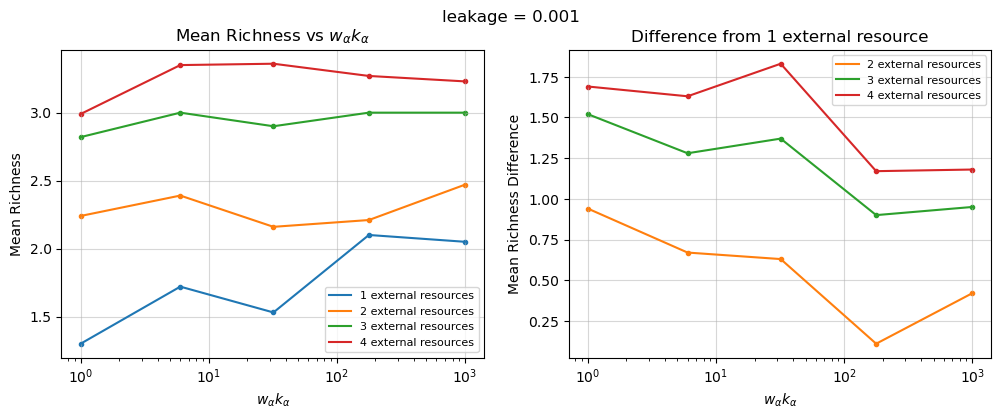

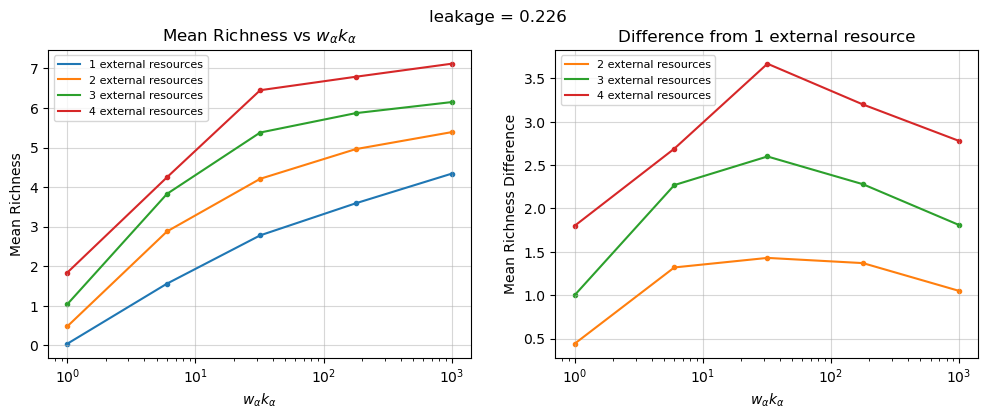

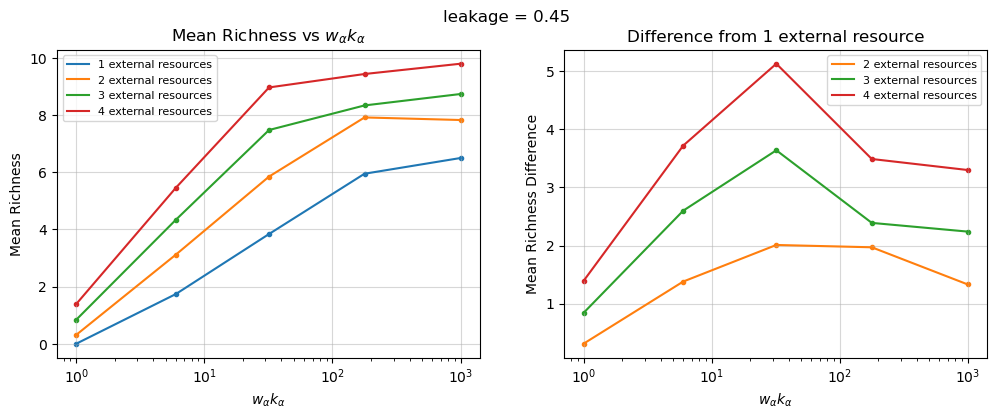

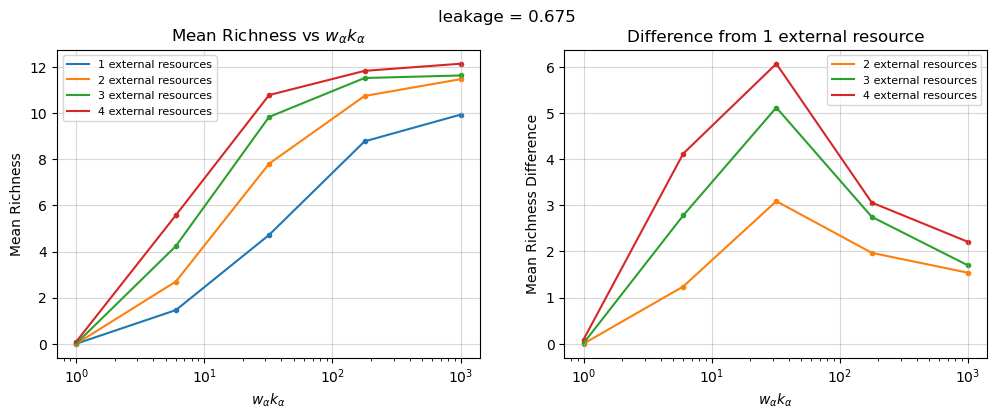

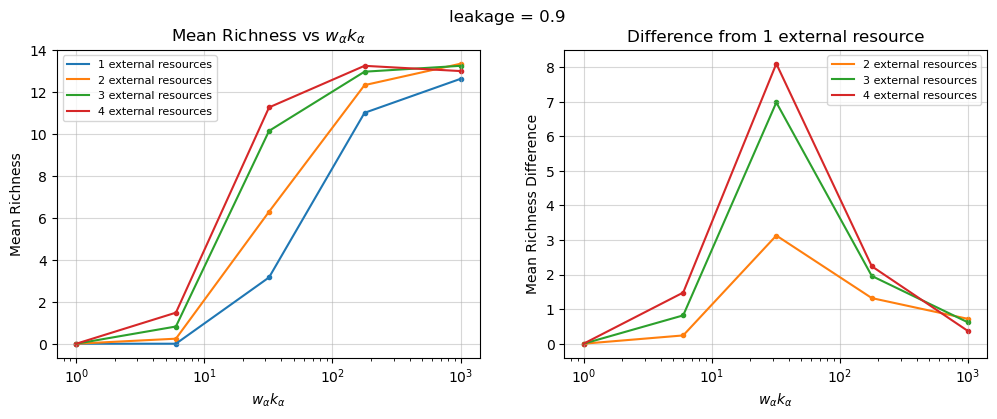

In [11]:
comparison_plots(l_0001, abs_diff_0001, "0.001")
comparison_plots(l_0226, abs_diff_0226, "0.226")
comparison_plots(l_045, abs_diff_045, "0.45")
comparison_plots(l_0675, abs_diff_0675, "0.675")
comparison_plots(l_09, abs_diff_09, "0.9")